In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.config.paths import MERGED_CSV, FIGURES_DIR

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
sns.set_style("whitegrid")

df = pd.read_csv(MERGED_CSV, low_memory=False)
print(df.shape)
df.head()

(27422, 49)


,designation,full_name,close_approach_date,distance_au,dist_km,dist_lunar,distance_min_au,distance_max_au,velocity_km_s,v_rel_kmh,...,first_obs,last_obs,data_arc,data_arc_years,orbit_stretch,interaction_index,size_energy_index,diameter_velocity_proxy,log_diameter,log_distance_au
0,2022 AP1,(2022 AP1),2015-01-01 00:27:00,0.045100,6746806.0,17.55,0.013778,0.076571,11.891749,42810.0,...,2022-01-04,2022-01-09,5.0,0.01,0.656,1112.347052,0.000056,0.088656,-2.127539,-1.345827
1,2015 AE45,(2015 AE45),2015-01-02 15:56:00,0.048239,7216474.0,18.77,0.048220,0.048258,7.065686,25436.0,...,2015-01-15,2015-02-19,35.0,0.10,0.827,30.863245,0.000957,0.218582,-1.509539,-1.316600
2,613286,613286 (2005 YQ96),2015-01-02 21:46:00,0.026522,3967664.0,10.32,0.026522,0.026522,12.703378,45732.0,...,2005-12-30,2023-12-15,6559.0,17.96,0.495,52.080621,0.070619,3.375827,-0.575539,-1.576391
3,2014 YQ34,(2014 YQ34),2015-01-03 13:29:00,0.079692,11921722.0,31.01,0.078275,0.081108,24.982094,89936.0,...,2014-12-23,2014-12-29,6.0,0.02,4.194,156.715248,0.002735,1.306441,-1.281539,-1.098586
4,2014 YE42,(2014 YE42),2015-01-03 15:00:00,0.010995,1644896.0,4.28,0.010971,0.011020,13.998882,50396.0,...,2014-12-30,2015-01-04,5.0,0.01,2.839,698.812020,0.005507,1.038854,-1.129539,-1.958787


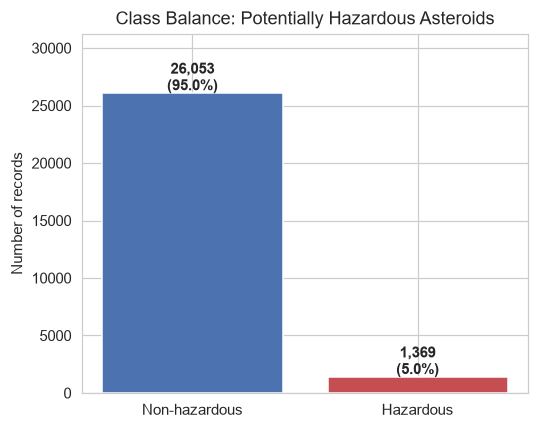

In [2]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["pha"].value_counts()
colors = ["#4C72B0", "#C44E52"]
ax.bar(["Non-hazardous", "Hazardous"], counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + len(df)*0.01, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")
ax.set_ylim(0, counts.values.max() * 1.2)
ax.set_title("Class Balance: Potentially Hazardous Asteroids")
ax.set_ylabel("Number of records")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_01_class_balance.png")
plt.show()

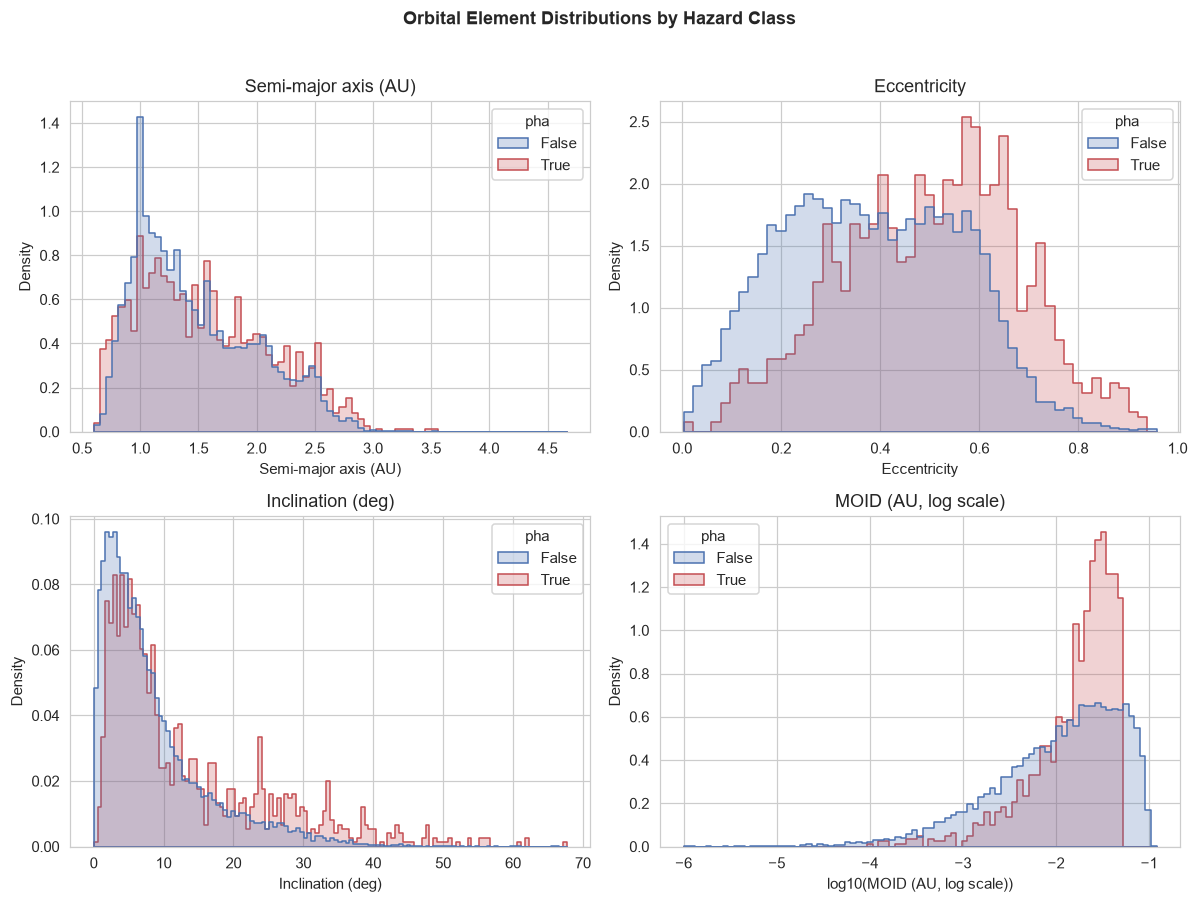

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features = {"a": "Semi-major axis (AU)", "e": "Eccentricity",
            "i": "Inclination (deg)", "moid_au": "MOID (AU, log scale)"}
for ax, (col, label) in zip(axes.flat, features.items()):
    data_plot = df.copy()
    use_log = col == "moid_au"
    if use_log:
        data_plot[col] = np.log10(data_plot[col].clip(lower=1e-6))
    sns.histplot(data=data_plot, x=col, hue="pha", element="step",
                  stat="density", common_norm=False, ax=ax, palette=colors)
    ax.set_xlabel(f"log10({label})" if use_log else label)
    ax.set_title(label)
plt.suptitle("Orbital Element Distributions by Hazard Class", y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_02_orbital_distributions.png", bbox_inches="tight")
plt.show()

In [4]:
rule_pred = (df["moid_au"] < 0.05) & (df["H"] <= 22.0)
match_rate = (rule_pred == df["pha"]).mean()
print(f"Simple 2-feature rule matches the 'pha' label: {match_rate:.4%}")
print()
print("Confusion of rule vs actual label:")
print(pd.crosstab(rule_pred, df["pha"], rownames=["rule_predicts_hazardous"], colnames=["actual_pha"]))
print()
print("IMPLICATION: any ML model trained with moid_au and H as features")
print("will achieve near-perfect accuracy almost entirely by reconstructing")
print("this rule, NOT by learning genuine predictive patterns. See")
print("src/models/risk_classifier.py for the two-feature-set fix (FEATURES_FULL")
print("vs FEATURES_NO_LEAK) used throughout the rest of this project.")

Simple 2-feature rule matches the 'pha' label: 99.8870%

Confusion of rule vs actual label:
actual_pha               False  True 
rule_predicts_hazardous              
False                    26044     22
True                         9   1347

IMPLICATION: any ML model trained with moid_au and H as features
will achieve near-perfect accuracy almost entirely by reconstructing
this rule, NOT by learning genuine predictive patterns. See
src/models/risk_classifier.py for the two-feature-set fix (FEATURES_FULL
vs FEATURES_NO_LEAK) used throughout the rest of this project.


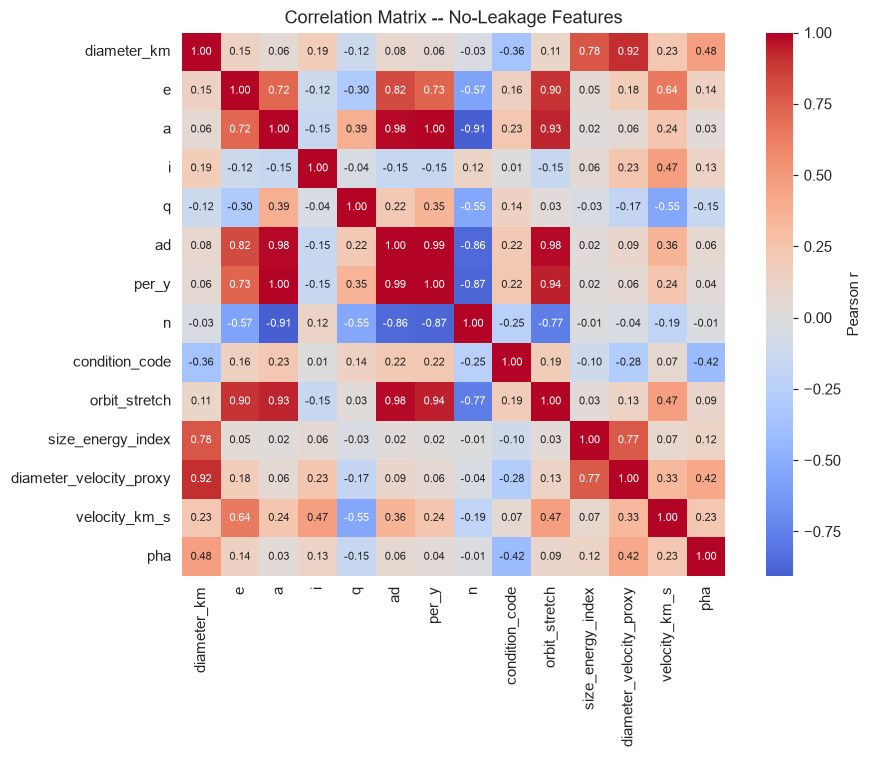

In [5]:
from src.models.risk_classifier import FEATURES_NO_LEAK

num_cols = FEATURES_NO_LEAK + ["pha"]
corr = df[num_cols].astype({"pha": int}).corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax,
            cbar_kws={"label": "Pearson r"}, annot_kws={"size": 7})
ax.set_title("Correlation Matrix -- No-Leakage Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_03_correlation_no_leak.png")
plt.show()

In [6]:
split_summary = df.groupby("is_future").agg(
    n_rows=("pha", "size"),
    n_unique_asteroids=("full_name", "nunique"),
    hazardous_rate=("pha", "mean"),
).round(4)
split_summary

,n_rows,n_unique_asteroids,hazardous_rate
is_future,,,
False,23537,19941,0.0367
True,3885,3289,0.1300
